### Project Overview

This project applies two machine learning models on an image classification task:
1. Logistic Regression (supervised learning)
2. K-Means clustering used as a classifier (unsupervised learning)

The objective is to classify images from the Fruits-360 dataset using handcrafted
features extracted via Histogram of Oriented Gradients (HOG).

The project includes:
- Feature extraction and dimensionality analysis
- Model training and evaluation
- Cross-validation
- Visualization of results including accuracy, confusion matrix, and ROC curves

In [123]:
import os
import cv2
import numpy as np
from skimage.feature import hog
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, auc,classification_report,roc_curve
from sklearn.preprocessing import StandardScaler, label_binarize

### Dataset Description

- **Dataset Name:** Fruits-360 (https://www.kaggle.com/datasets/moltean/fruits)
- **Data Type:** RGB images
- **Number of Classes:** 5

| Label | Class Name |
|-----|-----------|
| 0 | Apple Golden 1 |
| 1 | Banana 1 |
| 2 | Blackberrie 1 |
| 3 | Cantaloupe 1 |
| 4 | Cherry 1 |

- **Original Image Size:** 100 × 100 pixels
- **Resized Image Size:** 64 × 64 pixels
- **Total Number of Samples:** 2404
- **Training/Test Split:** 70% training, 30% testing


In [124]:
dataset_path = "/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training"

CLASSES = [
    "Apple Golden 1",
    "Banana 1",
    "Blackberrie 1",
    "Cantaloupe 1",
    "Cherry 1"
]

IMG_SIZE = 64
N_CLASSES = len(CLASSES)


In [125]:
images = []
labels = []

for label, class_name in enumerate(CLASSES):
    class_path = os.path.join(dataset_path, class_name)
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        images.append(img)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Total images:", images.shape)
print("Total labels:", labels.shape)

Total images: (2404, 64, 64, 3)
Total labels: (2404,)


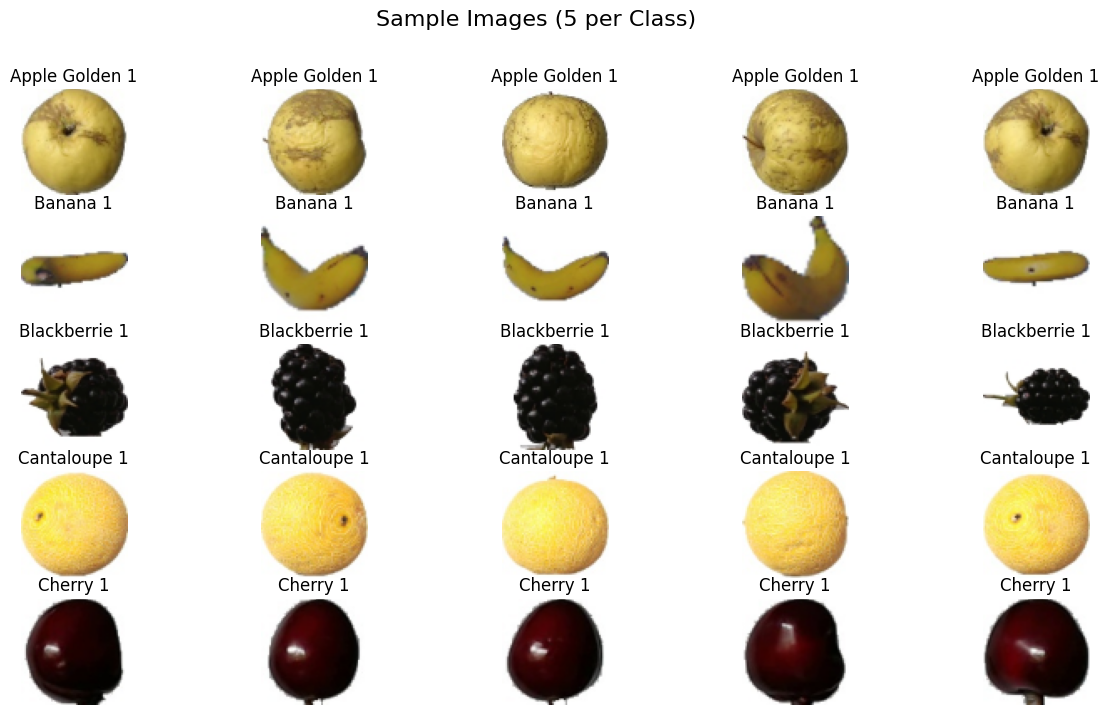

In [126]:
plt.figure(figsize=(15,8))
img_index = 1

for class_id, class_name in enumerate(CLASSES):
    class_images = images[labels == class_id][:5]
    
    for img in class_images:
        plt.subplot(len(CLASSES), 5, img_index)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(class_name)
        plt.axis("off")
        img_index += 1

plt.suptitle("Sample Images (5 per Class)", fontsize=16)
plt.show()


### RGB Channel Visualization

Before converting images to grayscale, the individual Red, Green, and Blue (RGB)
channels are visualized separately. This helps illustrate how color information is
distributed across channels and motivates the conversion to grayscale for
dimensionality reduction.

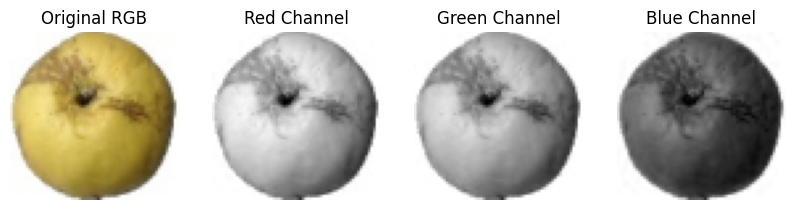

In [127]:
sample_img = images[0]


B, G, R = cv2.split(sample_img)

plt.figure(figsize=(10,3))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(R, cmap="gray")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(G, cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(B, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")

plt.show()


### Grayscale Conversion

Images are converted from RGB to grayscale to reduce dimensionality
and computational cost while preserving structural information.

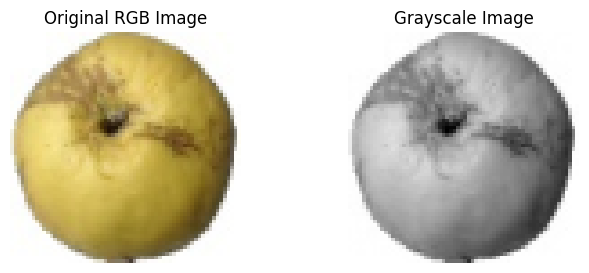

In [128]:
gray_images = []

for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray)

gray_images = np.array(gray_images)

# Visualize grayscale conversion
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_images[0], cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

### Image Normalization

Initially, Min–Max normalization was applied independently to each grayscale image
using the following formula:
$$
\text{norm}(I) = \frac{I - I_{\min}}{I_{\max} - I_{\min}}
$$

However, due to the controlled lighting conditions and uniform background in the
Fruits-360 dataset, the minimum and maximum pixel values within many images were
very close. As a result, Min–Max normalization caused most pixel values to become
very close to **1**, producing nearly uniform (almost white) images and reducing
useful intensity variations.

To address this issue, a global normalization strategy was adopted by scaling pixel
values to the range \([0, 1]\) using division by 255:

\[
I_{norm} = \frac{I}{255}
\]

This approach preserves relative intensity differences across images, avoids
numerical instability, and provides more meaningful input for HOG feature extraction
and subsequent classification models.

In [129]:
normalized_images = []

for img in gray_images:
    norm = img.astype(np.float32) / 255.0
    normalized_images.append(norm)

normalized_images = np.array(normalized_images)

print("Min pixel value:", normalized_images.min())
print("Max pixel value:", normalized_images.max())

normalized_images

Min pixel value: 0.0
Max pixel value: 1.0


array([[[1.        , 1.        , 1.        , ..., 0.99607843,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        ...,
        [1.        , 1.        , 0.99607843, ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ]],

       [[1.        , 1.        , 1.        , ..., 0.99607843,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 0.99607843,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 0.99607843,
         1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1. 

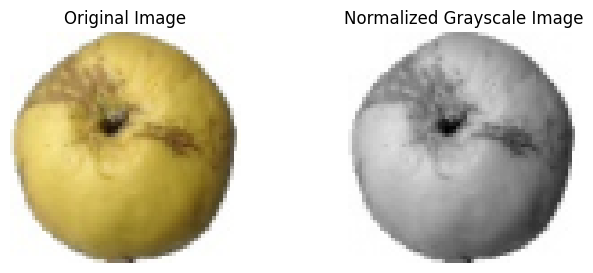

In [130]:
plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(normalized_images[0], cmap="gray")
plt.title("Normalized Grayscale Image")
plt.axis("off")

plt.show()


### Histogram of Oriented Gradients (HOG)

HOG extracts gradient orientation histograms from local regions of the image,
capturing edge and shape information.

HOG Parameters:
- Orientations: 9
- Pixels per cell: 8 × 8
- Cells per block: 2 × 2

Each image is represented by a fixed-length feature vector.


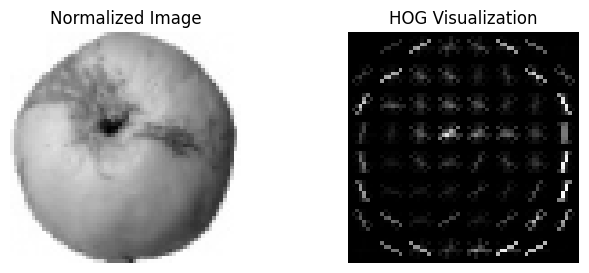

Total samples: 2404
HOG feature dimension per image: 1764


In [131]:
hog_features = []

hog_vector, hog_image = hog(
    normalized_images[0],
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm="L2-Hys"
)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.imshow(normalized_images[0], cmap="gray")
plt.title("Normalized Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Visualization")
plt.axis("off")
plt.show()

for img in normalized_images:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    hog_features.append(features)

X = np.array(hog_features)
y = labels

print("Total samples:", X.shape[0])
print("HOG feature dimension per image:", X.shape[1])


### Dataset Splitting

The dataset is split into:
- 70% training data
- 30% testing data

Cross-validation is applied only on the training data.


In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
)


### Logistic Regression Model

Logistic Regression is used as a supervised multi-class classifier.

Hyperparameters:
- Solver: LBFGS
- Regularization: L2
- Regularization strength (C): 1.0
- Maximum iterations: 2000
- Loss function: Cross-entropy


In [133]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000, C=1.0)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)


### Logistic Regression Results (Testing Data)

Evaluation metrics:
- Accuracy
- Confusion Matrix



Test Accuracy: 1.0
                precision    recall  f1-score   support

Apple Golden 1       1.00      1.00      1.00       154
      Banana 1       1.00      1.00      1.00       147
 Blackberrie 1       1.00      1.00      1.00       122
  Cantaloupe 1       1.00      1.00      1.00       150
      Cherry 1       1.00      1.00      1.00       149

      accuracy                           1.00       722
     macro avg       1.00      1.00      1.00       722
  weighted avg       1.00      1.00      1.00       722



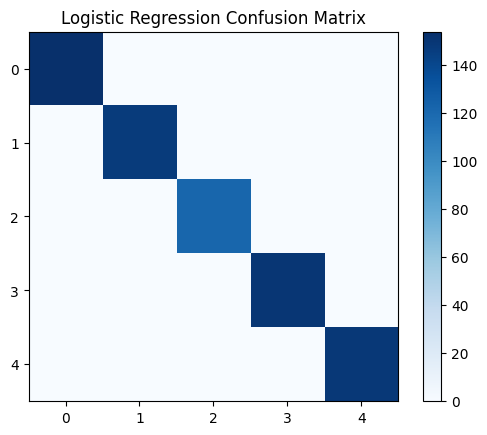

In [134]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.colorbar()
plt.show()





### K-Means Clustering

K-Means is an unsupervised learning algorithm used here as a classifier by
assigning each cluster to the most frequent class label within that cluster.


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


K-Means Accuracy: 0.6925207756232687
                precision    recall  f1-score   support

Apple Golden 1       0.47      1.00      0.64       154
      Banana 1       0.79      0.87      0.83       147
 Blackberrie 1       0.82      0.57      0.67       122
  Cantaloupe 1       0.00      0.00      0.00       150
      Cherry 1       0.99      1.00      0.99       149

      accuracy                           0.69       722
     macro avg       0.61      0.69      0.63       722
  weighted avg       0.60      0.69      0.62       722



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


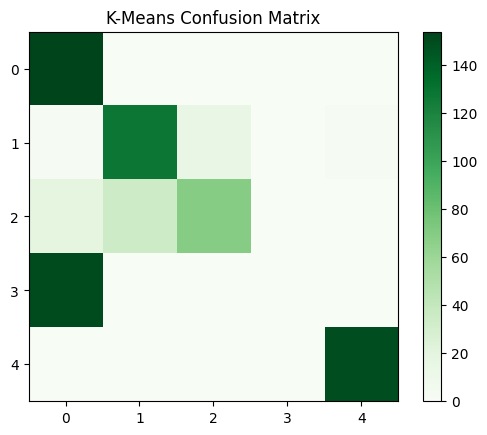

In [135]:
kmeans = KMeans(n_clusters=len(CLASSES), random_state=42)
kmeans.fit(X_train)

clusters = kmeans.predict(X_test)

cluster_map = {}
for c in np.unique(clusters):
    cluster_map[c] = np.bincount(y_test[clusters == c]).argmax()

y_pred_km = np.array([cluster_map[c] for c in clusters])

print("K-Means Accuracy:", accuracy_score(y_test, y_pred_km))
print(classification_report(y_test, y_pred_km, target_names=CLASSES))

cm_km = confusion_matrix(y_test, y_pred_km)
plt.imshow(cm_km, cmap="Greens")
plt.title("K-Means Confusion Matrix")
plt.colorbar()
plt.show()
